# 04 – Pure Premium
Combine frequency and severity GLMs to compute pure premium.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
from glm_pricing.pipeline import run_pipeline

results = run_pipeline(
    "../data/sample/freMTPL_sample.csv",
    "../data/sample/freMTPL_sample.csv",
)
metrics = results["metrics"]
print("Pipeline metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.6f}" if isinstance(v, float) else f"  {k}: {v}")


Pipeline metrics:
  poisson_deviance: 0.364324
  gamma_deviance: 20.756252
  freq_gini: 0.311800


In [3]:
from glm_pricing.evaluation import lift_chart, gini, calibration
import numpy as np

test = results["test"]
pp = results["pure_premium_test"]

# Gini on claim counts using pure premium as ranker
g = gini(test["ClaimNb"].astype(float).values, pp.values)
print(f"Normalized Gini (pure premium vs ClaimNb): {g:.4f}")


Normalized Gini (pure premium vs ClaimNb): 0.2743


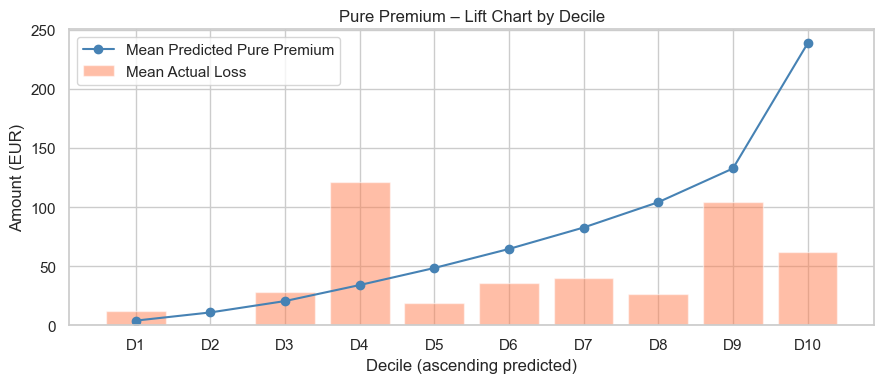

In [4]:
# Lift chart: pure premium vs actual claim amount
actual = test["ClaimAmountTotal"].values
lc = lift_chart(actual, pp.values, n_bins=10)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(lc))
ax.bar(x, lc["mean_actual"], alpha=0.5, label="Mean Actual Loss", color="coral")
ax.plot(x, lc["mean_pred"], marker="o", color="steelblue", label="Mean Predicted Pure Premium")
ax.set_xticks(x)
ax.set_xticklabels([f"D{i+1}" for i in x])
ax.set_title("Pure Premium – Lift Chart by Decile")
ax.set_xlabel("Decile (ascending predicted)")
ax.set_ylabel("Amount (EUR)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/sample/pure_premium_lift.png", dpi=80)
plt.show()


In [5]:
# Calibration
cal = calibration(actual, pp.values, n_bins=10)
print("Calibration table (ratio = actual/predicted):")
print(cal[["bin","mean_pred","mean_actual","ratio"]].to_string(index=False))


Calibration table (ratio = actual/predicted):
 bin  mean_pred  mean_actual    ratio
   0   3.853671      12.0400 3.124293
   1  10.787864       0.0000 0.000000
   2  20.413604      28.2231 1.382563
   3  33.966387     120.8100 3.556752
   4  48.396790      19.0488 0.393596
   5  64.515021      35.8414 0.555551
   6  82.655362      40.2052 0.486420
   7 104.085058      26.6640 0.256175
   8 132.628994     103.8926 0.783332
   9 238.405566      61.5622 0.258225


## Conclusion

The two-part GLM pricing model:
- **Frequency model (Poisson + log link + exposure offset):** captures the expected number of claims per policy-year. Key risk drivers include BonusMalus, driver age, vehicle age, and geographic density.
- **Severity model (Gamma + log link, weighted by ClaimNb):** estimates average claim cost conditional on a claim occurring.
- **Pure premium = E[Frequency] × E[Severity]** provides an actuarially fair base rate per policy.

**Next steps:**
1. Run on full 678k-policy dataset for production-quality estimates.
2. Add interaction terms and regularization (Elastic-Net GLM).
3. Benchmark against gradient boosted trees (XGBoost, LightGBM).
4. Incorporate geographic features (spatial smoothing by region).
5. Add pricing layer (add loadings for expenses, profit).
